<a href="https://colab.research.google.com/github/preetidehingia02-ui/APPLICATION-OF-MACHINE-LEARNING-FOR-PRODUCTION-FORECASTING-PRESSURE-ANOMALY-DETECTION/blob/main/F12_Pressure_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛢️ F-12 Historical Pressure Anomaly Detection
**Volve Production Dataset · Well: NO 15/9-F-12 H · Period: 2008 – 2010**

---
**Workflow**
1. Load & Filter Data
2. Prepare Pressure Dataset
3. Normal Pressure Behaviour
4. Statistical Anomaly Detection (30-day rolling window)
5. Pressure Spike Detection
6. Combined Anomaly Master List
7. Root-Cause Investigation (Shutdown / Choke / Water Breakthrough / Gas Coning)
8. Isolation Forest (Multivariate ML)
9. Confidence Classification
10. Final Anomaly Table
11. Diagnostic Figures (4 plots)
12. Summary Report

## ⚙️ Install & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from google.colab import files
import io

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 📂 Upload Dataset

In [2]:
# Upload your Volve_production_data.xlsx file
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f'✅ Uploaded: {filename}')

Saving Volve production data.xlsx to Volve production data (1).xlsx
✅ Uploaded: Volve production data (1).xlsx


---
## STEP 1 — Load and Filter Data

In [3]:
# ── Load ──────────────────────────────────────────────────────
raw = pd.read_excel(io.BytesIO(uploaded[filename]),
                    sheet_name='Daily Production Data')

print(f'Dataset shape  : {raw.shape[0]:,} rows × {raw.shape[1]} columns')
print(f'Columns        : {list(raw.columns)}')

# ── Filter F-12 ───────────────────────────────────────────────
df_well = raw[raw['WELL_BORE_CODE'].astype(str).str.contains('F-12', na=False)].copy()

# ── Convert and sort dates ────────────────────────────────────
df_well['DATEPRD'] = pd.to_datetime(df_well['DATEPRD'], errors='coerce')
df_well.sort_values('DATEPRD', inplace=True)
df_well.reset_index(drop=True, inplace=True)

print(f'\nWell F-12 rows : {len(df_well):,}')
print(f'Date range     : {df_well["DATEPRD"].min().date()} → {df_well["DATEPRD"].max().date()}')
print(f'Well code      : {df_well["WELL_BORE_CODE"].unique()}')

df_well.head(3)

Dataset shape  : 15,634 rows × 24 columns
Columns        : ['DATEPRD', 'WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'AVG_CHOKE_UOM', 'AVG_WHP_P', 'AVG_WHT_P', 'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL', 'BORE_WI_VOL', 'FLOW_KIND', 'WELL_TYPE']

Well F-12 rows : 3,056
Date range     : 2008-02-12 → 2016-09-17
Well code      : ['NO 15/9-F-12 H']


,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2008-02-12,NO 15/9-F-12 H,5599,15/9-F-12,3420717,VOLVE,369304,MÆRSK INSPIRER,11.5,308.055940,...,%,106.805939,16.294718,92.475107,284.65,38888.67,385.01,NaN,production,OP
1,2008-02-13,NO 15/9-F-12 H,5599,15/9-F-12,3420717,VOLVE,369304,MÆRSK INSPIRER,24.0,303.033518,...,%,120.888576,53.374330,89.620148,1869.70,285246.16,7.13,NaN,production,OP
2,2008-02-14,NO 15/9-F-12 H,5599,15/9-F-12,3420717,VOLVE,369304,MÆRSK INSPIRER,22.5,295.586061,...,%,113.718175,72.737631,80.120465,3124.09,509954.88,1.16,NaN,production,OP


---
## STEP 2 — Prepare Pressure Dataset

In [4]:
# ── Select, clean and filter 2008-2010 ───────────────────────
df_press = (
    df_well[['DATEPRD', 'AVG_DOWNHOLE_PRESSURE']]
    .rename(columns={'DATEPRD': 'Date', 'AVG_DOWNHOLE_PRESSURE': 'Downhole_Pressure'})
    .dropna(subset=['Downhole_Pressure'])           # remove nulls
    .query('Downhole_Pressure > 0')                 # remove zeros
    .query('Date >= "2008-01-01" and Date <= "2010-12-31"')  # valid window
    .drop_duplicates('Date')
    .set_index('Date')
    .sort_index()
)

print(f'Valid pressure readings (2008–2010): {len(df_press):,}')
print(f'Date range : {df_press.index.min().date()} → {df_press.index.max().date()}')
print('\nSample:')
df_press.head(10)

Valid pressure readings (2008–2010): 955
Date range : 2008-02-12 → 2010-10-11

Sample:


,Downhole_Pressure
Date,
2008-02-12,308.055940
2008-02-13,303.033518
2008-02-14,295.586061
2008-02-15,297.662702
2008-02-16,295.935519
2008-02-17,295.551657
2008-02-18,294.211063
2008-02-19,293.829243
2008-02-20,293.061480


---
## STEP 3 — Normal Pressure Behaviour

  NORMAL PRESSURE BEHAVIOUR — F-12
  Mean Pressure   : 257.83 bar
  Std Deviation   : 19.53 bar
  Min Pressure    : 140.26 bar
  Max Pressure    : 317.70 bar
  Normal Range    : [199.24, 316.41] bar  (±3σ global)


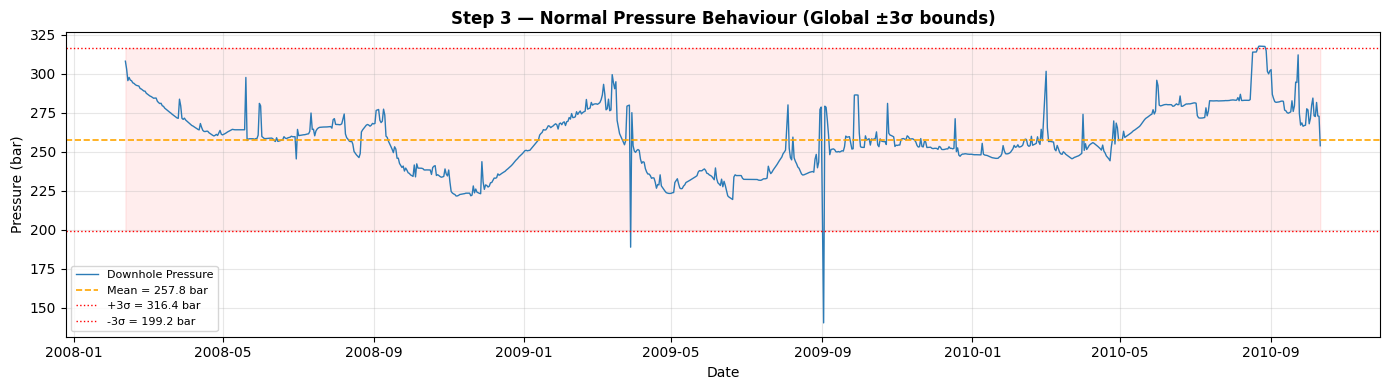

In [5]:
p      = df_press['Downhole_Pressure']
p_mean = p.mean()
p_std  = p.std()
p_min  = p.min()
p_max  = p.max()

print('='*50)
print('  NORMAL PRESSURE BEHAVIOUR — F-12')
print('='*50)
print(f'  Mean Pressure   : {p_mean:.2f} bar')
print(f'  Std Deviation   : {p_std:.2f} bar')
print(f'  Min Pressure    : {p_min:.2f} bar')
print(f'  Max Pressure    : {p_max:.2f} bar')
print(f'  Normal Range    : [{p_mean - 3*p_std:.2f}, {p_mean + 3*p_std:.2f}] bar  (±3σ global)')
print('='*50)

# Quick overview plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(p.index, p, color='#2c7bb6', linewidth=1, label='Downhole Pressure')
ax.axhline(p_mean, color='orange', linestyle='--', linewidth=1.2, label=f'Mean = {p_mean:.1f} bar')
ax.axhline(p_mean + 3*p_std, color='red', linestyle=':', linewidth=1, label=f'+3σ = {p_mean+3*p_std:.1f} bar')
ax.axhline(p_mean - 3*p_std, color='red', linestyle=':', linewidth=1, label=f'-3σ = {p_mean-3*p_std:.1f} bar')
ax.fill_between(p.index, p_mean - 3*p_std, p_mean + 3*p_std, alpha=0.07, color='red')
ax.set_title('Step 3 — Normal Pressure Behaviour (Global ±3σ bounds)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Pressure (bar)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## STEP 4 — Statistical Anomaly Detection (30-day Rolling Window)

In [6]:
ROLL_WINDOW = '30D'
MIN_PERIODS = 5

roll       = p.rolling(ROLL_WINDOW, min_periods=MIN_PERIODS)
roll_mean  = roll.mean()
roll_std   = roll.std()

upper_bound = roll_mean + 3 * roll_std
lower_bound = roll_mean - 3 * roll_std

stat_mask  = (p > upper_bound) | (p < lower_bound)
stat_anom  = df_press[stat_mask].copy()
stat_anom['Statistical'] = True

print(f'Rolling window  : {ROLL_WINDOW}  (min {MIN_PERIODS} periods)')
print(f'Statistical anomalies detected : {len(stat_anom)}')
print('\nAnomaly dates (Statistical):')
print(stat_anom[['Downhole_Pressure']].rename(columns={'Downhole_Pressure':'Pressure (bar)'}).to_string())

Rolling window  : 30D  (min 5 periods)
Statistical anomalies detected : 17

Anomaly dates (Statistical):
            Pressure (bar)
Date                      
2008-05-20      297.645970
2008-07-12      274.830623
2008-11-03      224.533323
2008-11-28      243.631086
2009-03-07      293.230170
2009-03-14      299.454260
2009-03-29      188.802500
2009-08-04      280.049730
2009-09-02      140.256360
2009-12-18      271.188724
2010-03-02      301.587800
2010-04-01      274.006982
2010-05-31      295.846976
2010-07-03      273.163190
2010-07-04      271.796269
2010-08-17      313.881390
2010-08-20      313.978470


---
## STEP 5 — Pressure Spike Detection

In [7]:
daily_change    = p.diff()
spike_threshold = 3 * daily_change.std()
spike_mask      = daily_change.abs() > spike_threshold

spike_anom = df_press[spike_mask].copy()
spike_anom['Daily_Change'] = daily_change[spike_mask]
spike_anom['Spike'] = True

print(f'Daily Δ Pressure std    : {daily_change.std():.2f} bar/day')
print(f'Spike threshold (±3σ)  : {spike_threshold:.2f} bar/day')
print(f'Spike anomalies detected: {len(spike_anom)}')
print('\nSpike anomaly dates:')
display(spike_anom[['Downhole_Pressure','Daily_Change']])

Daily Δ Pressure std    : 9.38 bar/day
Spike threshold (±3σ)  : 28.14 bar/day
Spike anomalies detected: 13

Spike anomaly dates:


,Downhole_Pressure,Daily_Change
Date,,
2008-05-20,297.645970,33.558080
2008-05-21,257.200000,-40.445970
2009-03-29,188.802500,-91.098900
2009-03-30,275.054231,86.251731
2009-08-04,280.049730,29.017709
2009-08-30,277.120740,33.786859
2009-09-02,140.256360,-138.389890
2009-09-03,279.223200,138.966840
2009-09-27,286.312730,34.365218


---
## STEP 6 — Combined Anomaly Master List

In [8]:
all_dates = stat_anom.index.union(spike_anom.index)
master    = pd.DataFrame(index=all_dates)
master.index.name = 'Date'

master['Pressure']    = p[all_dates]
master['Statistical'] = master.index.isin(stat_anom.index)
master['Spike']       = master.index.isin(spike_anom.index)
master.sort_index(inplace=True)

print(f'Total unique anomaly dates: {len(master)}')
print(f'  Statistical only  : {(master["Statistical"] & ~master["Spike"]).sum()}')
print(f'  Spike only        : {(~master["Statistical"] & master["Spike"]).sum()}')
print(f'  Both methods      : {(master["Statistical"] & master["Spike"]).sum()}')
print('\nMaster Anomaly List:')
display(master)

Total unique anomaly dates: 24
  Statistical only  : 11
  Spike only        : 7
  Both methods      : 6

Master Anomaly List:


,Pressure,Statistical,Spike
Date,,,
2008-05-20,297.645970,True,True
2008-05-21,257.200000,False,True
2008-07-12,274.830623,True,False
2008-11-03,224.533323,True,False
2008-11-28,243.631086,True,False
2009-03-07,293.230170,True,False
2009-03-14,299.454260,True,False
2009-03-29,188.802500,True,True
2009-03-30,275.054231,False,True


---
## STEP 7 — Root-Cause Investigation

In [9]:
# Prepare aligned full dataset (2008-2010)
full = (
    df_well
    .set_index('DATEPRD')
    .sort_index()
    .loc['2008-01-01':'2010-12-31']
)

WINDOW = 7  # days either side of the anomaly

def get_window(col, date, days=WINDOW):
    """Return a Series slice ±days around the anomaly date."""
    idx = pd.date_range(date - pd.Timedelta(days=days),
                        date + pd.Timedelta(days=days), freq='D')
    return full[col].reindex(idx).dropna() if col in full.columns else pd.Series(dtype=float)


def get_cause(date):
    causes = []

    # ── CHECK 1: Shutdown ──────────────────────────────────────
    hrs = get_window('ON_STREAM_HRS', date)
    if not hrs.empty and (hrs == 0).any():
        causes.append('Shutdown')

    # ── CHECK 2: Choke Change ──────────────────────────────────
    chk = get_window('AVG_CHOKE_SIZE_P', date)
    if len(chk) >= 2 and chk.mean() > 0 and (chk.std() / chk.mean()) > 0.15:
        causes.append('Choke Change')

    # ── CHECK 3: Water Breakthrough ───────────────────────────
    oil = get_window('BORE_OIL_VOL', date)
    wat = get_window('BORE_WAT_VOL', date)
    if len(oil) >= 2 and len(wat) >= 2:
        common_idx = oil.index.intersection(wat.index)
        if len(common_idx) >= 2:
            total = oil[common_idx] + wat[common_idx]
            wcut  = (wat[common_idx] / total.replace(0, np.nan)).dropna()
            press_w = p.reindex(common_idx, method='nearest',
                                tolerance=pd.Timedelta('2D')).dropna()
            if len(wcut) >= 2 and wcut.iloc[-1] > wcut.iloc[0]:
                if len(press_w) >= 2 and press_w.iloc[-1] < press_w.iloc[0]:
                    causes.append('Water Breakthrough')

    # ── CHECK 4: Gas Coning ────────────────────────────────────
    gas = get_window('BORE_GAS_VOL', date)
    oil2 = get_window('BORE_OIL_VOL', date)
    if len(gas) >= 2 and len(oil2) >= 2:
        common_idx2 = gas.index.intersection(oil2.index)
        if len(common_idx2) >= 2:
            gor = (gas[common_idx2] / oil2[common_idx2].replace(0, np.nan)).dropna()
            if len(gor) >= 2 and gor.iloc[-1] > gor.iloc[0] * 1.2:
                causes.append('Gas Coning')

    return ', '.join(causes) if causes else 'Unexplained'


master['Cause'] = [get_cause(d) for d in master.index]

print('Root-cause investigation complete')
display(master[['Pressure','Statistical','Spike','Cause']])

Root-cause investigation complete


,Pressure,Statistical,Spike,Cause
Date,,,,
2008-05-20,297.645970,True,True,Water Breakthrough
2008-05-21,257.200000,False,True,Water Breakthrough
2008-07-12,274.830623,True,False,Unexplained
2008-11-03,224.533323,True,False,"Choke Change, Water Breakthrough"
2008-11-28,243.631086,True,False,Unexplained
2009-03-07,293.230170,True,False,Shutdown
2009-03-14,299.454260,True,False,"Shutdown, Choke Change"
2009-03-29,188.802500,True,True,"Shutdown, Choke Change"
2009-03-30,275.054231,False,True,"Shutdown, Choke Change, Water Breakthrough"


---
## STEP 8 — Isolation Forest (Multivariate ML)

In [10]:
IF_FEATURES = ['AVG_WHP_P', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS',
               'AVG_CHOKE_SIZE_P', 'AVG_WHT_P']

avail = [c for c in IF_FEATURES if c in full.columns]
print(f'IF features available: {avail}')

ml_df = full[avail].dropna().copy()

scaler = StandardScaler()
X      = scaler.fit_transform(ml_df)

iso = IsolationForest(n_estimators=200,
                      contamination=0.05,
                      random_state=42,
                      n_jobs=-1)
ml_df['IF_Label'] = iso.fit_predict(X)
ml_df['IF_Score'] = iso.score_samples(X)   # lower = more anomalous

if_anom = ml_df[ml_df['IF_Label'] == -1][['IF_Score']].copy()
if_anom.index.name = 'Date'

print(f'\nIsolation Forest anomalies: {len(if_anom)}')
print(f'Anomaly score range       : [{if_anom["IF_Score"].min():.4f}, {if_anom["IF_Score"].max():.4f}]')
display(if_anom.head(10))

IF features available: ['AVG_WHP_P', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'AVG_WHT_P']

Isolation Forest anomalies: 50
Anomaly score range       : [-0.7929, -0.5475]


,IF_Score
Date,
2008-02-12,-0.719995
2008-02-13,-0.645241
2008-02-15,-0.594656
2008-02-19,-0.547463
2008-02-20,-0.551744
2008-02-21,-0.551912
2008-02-22,-0.593612
2008-03-08,-0.557513
2008-03-28,-0.704011


---
## STEP 9 — Confidence Classification

In [11]:
master['IF']      = master.index.isin(if_anom.index)
master['Methods'] = (master['Statistical'].astype(int) +
                     master['Spike'].astype(int) +
                     master['IF'].astype(int))

def classify(row):
    if row['Methods'] >= 3: return 'High'
    if row['Methods'] == 2: return 'Medium'
    return 'Low'

def method_str(row):
    m = []
    if row['Statistical']: m.append('Statistical')
    if row['Spike']:        m.append('Spike')
    if row['IF']:           m.append('IF')
    return ' + '.join(m) if m else 'None'

master['Confidence']       = master.apply(classify, axis=1)
master['Detection_Method'] = master.apply(method_str, axis=1)

conf_counts = master['Confidence'].value_counts()
print('Confidence breakdown:')
for level in ['High','Medium','Low']:
    print(f'  {level:<8}: {conf_counts.get(level, 0)}')

display(master[['Pressure','Detection_Method','Confidence','Cause']])

Confidence breakdown:
  High    : 1
  Medium  : 8
  Low     : 15


,Pressure,Detection_Method,Confidence,Cause
Date,,,,
2008-05-20,297.645970,Statistical + Spike,Medium,Water Breakthrough
2008-05-21,257.200000,Spike,Low,Water Breakthrough
2008-07-12,274.830623,Statistical + IF,Medium,Unexplained
2008-11-03,224.533323,Statistical,Low,"Choke Change, Water Breakthrough"
2008-11-28,243.631086,Statistical,Low,Unexplained
2009-03-07,293.230170,Statistical,Low,Shutdown
2009-03-14,299.454260,Statistical,Low,"Shutdown, Choke Change"
2009-03-29,188.802500,Statistical + Spike,Medium,"Shutdown, Choke Change"
2009-03-30,275.054231,Spike + IF,Medium,"Shutdown, Choke Change, Water Breakthrough"


---
## STEP 10 — Final Anomaly Table

In [12]:
final_table = master[['Pressure','Detection_Method','Cause','Confidence']].copy()
final_table.index = final_table.index.strftime('%Y-%m-%d')
final_table.index.name = 'Date'
final_table.columns = ['Pressure (bar)', 'Detection Method', 'Cause', 'Confidence']

print('='*80)
print('FINAL ANOMALY TABLE — Well F-12 (2008–2010)')
print('='*80)
display(final_table)

# Save as CSV
csv_bytes = final_table.to_csv().encode()
with open('F12_anomaly_table.csv', 'wb') as f:
    f.write(csv_bytes)
print('\n✅ Saved: F12_anomaly_table.csv')
files.download('F12_anomaly_table.csv')

FINAL ANOMALY TABLE — Well F-12 (2008–2010)


,Pressure (bar),Detection Method,Cause,Confidence
Date,,,,
2008-05-20,297.645970,Statistical + Spike,Water Breakthrough,Medium
2008-05-21,257.200000,Spike,Water Breakthrough,Low
2008-07-12,274.830623,Statistical + IF,Unexplained,Medium
2008-11-03,224.533323,Statistical,"Choke Change, Water Breakthrough",Low
2008-11-28,243.631086,Statistical,Unexplained,Low
2009-03-07,293.230170,Statistical,Shutdown,Low
2009-03-14,299.454260,Statistical,"Shutdown, Choke Change",Low
2009-03-29,188.802500,Statistical + Spike,"Shutdown, Choke Change",Medium
2009-03-30,275.054231,Spike + IF,"Shutdown, Choke Change, Water Breakthrough",Medium



✅ Saved: F12_anomaly_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## STEP 11 — Diagnostic Figures

In [13]:
# ── Colour palette ────────────────────────────────────────────
C = {
    'pressure'  : '#2c7bb6',
    'bounds'    : '#d7191c',
    'roll_mean' : '#fdae61',
    'anomaly'   : '#d7191c',
    'spike'     : '#e66101',
    'if_anom'   : '#7b2d8b',
    'shutdown'  : '#d7191c',
    'choke'     : '#fdae61',
    'water'     : '#2c7bb6',
    'gas'       : '#1a9641',
    'unexplain' : '#888888',
}

cause_palette = {
    'Shutdown'           : C['shutdown'],
    'Choke Change'       : C['choke'],
    'Water Breakthrough' : C['water'],
    'Gas Coning'         : C['gas'],
    'Unexplained'        : C['unexplain'],
}

print('Colour palette ready ✅')

Colour palette ready ✅


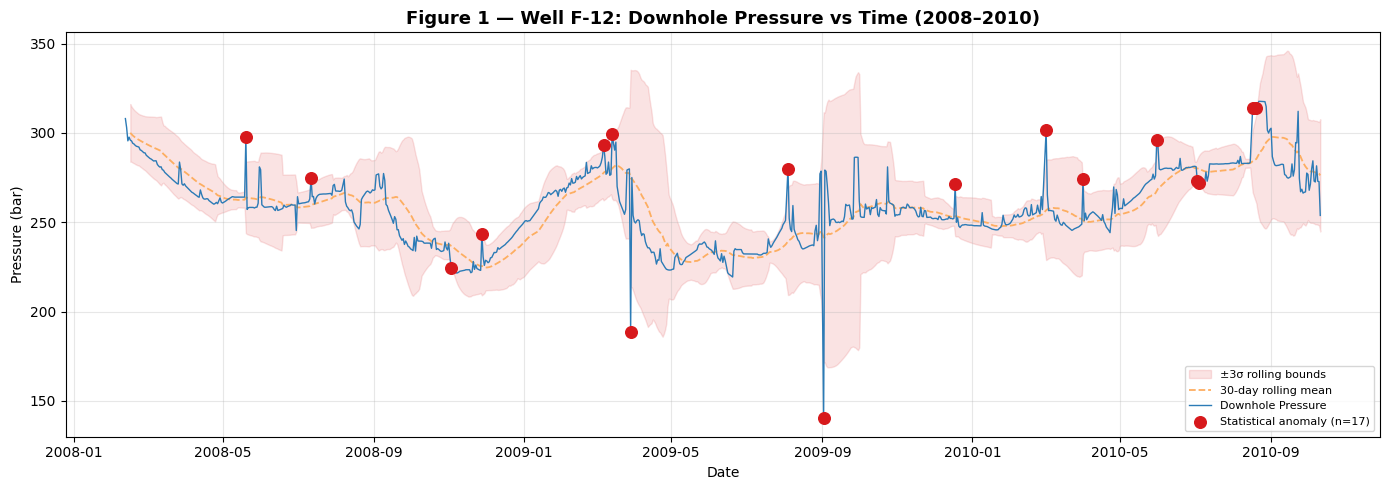

✅ Figure 1 saved


In [14]:
# ══════════════════════════════════════════════════════════════
# FIGURE 1 — Pressure vs Time with statistical anomaly points
# ══════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(14, 5))

ax1.fill_between(p.index, lower_bound, upper_bound,
                 alpha=0.12, color=C['bounds'], label='±3σ rolling bounds')
ax1.plot(p.index, roll_mean, color=C['roll_mean'],
         linewidth=1.3, linestyle='--', label='30-day rolling mean')
ax1.plot(p.index, p, color=C['pressure'],
         linewidth=1, label='Downhole Pressure')
ax1.scatter(stat_anom.index, stat_anom['Downhole_Pressure'],
            color=C['anomaly'], zorder=5, s=70,
            label=f'Statistical anomaly (n={len(stat_anom)})')

ax1.set_title('Figure 1 — Well F-12: Downhole Pressure vs Time (2008–2010)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Date'); ax1.set_ylabel('Pressure (bar)')
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('F12_Fig1_Pressure_vs_Time.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 1 saved')

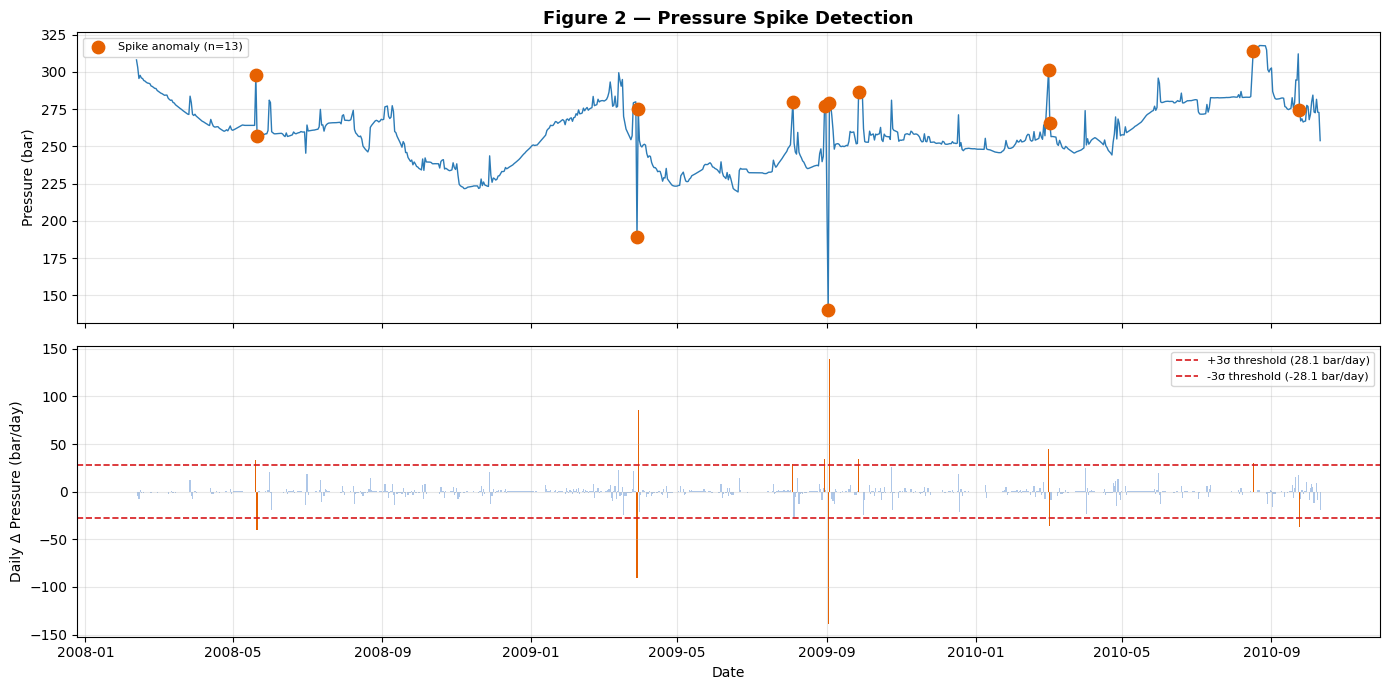

✅ Figure 2 saved


In [15]:
# ══════════════════════════════════════════════════════════════
# FIGURE 2 — Pressure Spike Detection
# ══════════════════════════════════════════════════════════════
fig2, (ax2a, ax2b) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: pressure with spike markers
ax2a.plot(p.index, p, color=C['pressure'], linewidth=1)
ax2a.scatter(spike_anom.index, spike_anom['Downhole_Pressure'],
             color=C['spike'], zorder=5, s=80,
             label=f'Spike anomaly (n={len(spike_anom)})')
ax2a.set_ylabel('Pressure (bar)')
ax2a.set_title('Figure 2 — Pressure Spike Detection', fontsize=13, fontweight='bold')
ax2a.legend(fontsize=8); ax2a.grid(True, alpha=0.3)

# Bottom: daily change bar chart
bar_colors = [C['spike'] if m else '#aec7e8' for m in spike_mask]
ax2b.bar(daily_change.index, daily_change.values, color=bar_colors, width=1)
ax2b.axhline( spike_threshold, color=C['bounds'], linestyle='--', linewidth=1.2,
              label=f'+3σ threshold ({spike_threshold:.1f} bar/day)')
ax2b.axhline(-spike_threshold, color=C['bounds'], linestyle='--', linewidth=1.2,
              label=f'-3σ threshold ({-spike_threshold:.1f} bar/day)')
ax2b.set_ylabel('Daily Δ Pressure (bar/day)')
ax2b.set_xlabel('Date')
ax2b.legend(fontsize=8); ax2b.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('F12_Fig2_Spike_Detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 saved')

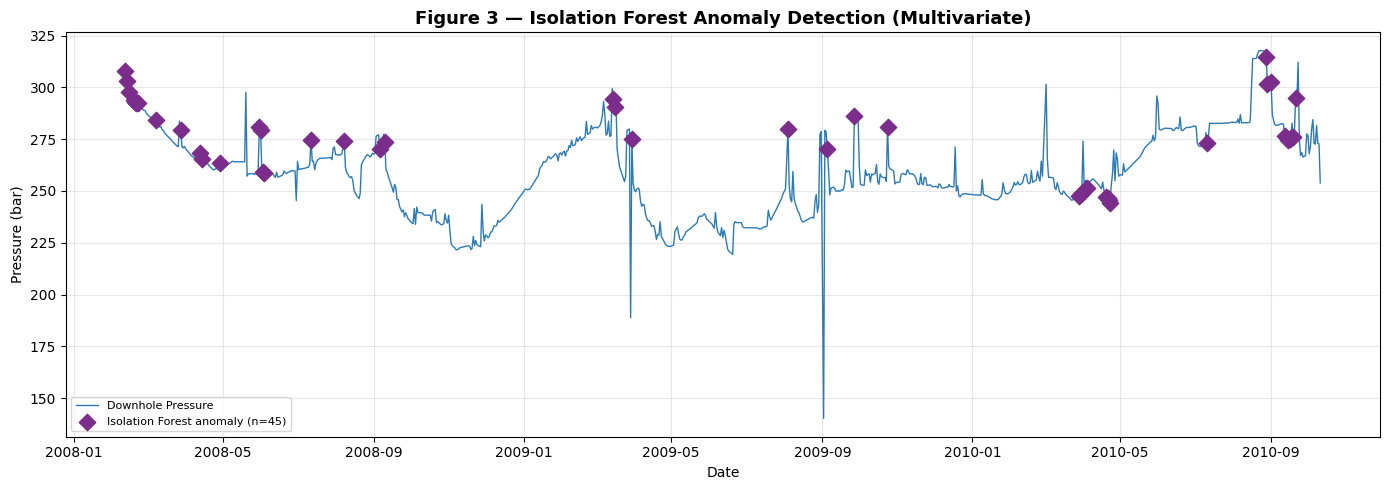

✅ Figure 3 saved


In [16]:
# ══════════════════════════════════════════════════════════════
# FIGURE 3 — Isolation Forest Anomalies
# ══════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(14, 5))

ax3.plot(p.index, p, color=C['pressure'], linewidth=1, label='Downhole Pressure')

if not if_anom.empty:
    if_dates  = if_anom.index.intersection(p.index)
    # also try nearest-date match for non-exact
    if_in_press = p.reindex(if_anom.index, method='nearest',
                            tolerance=pd.Timedelta('2D')).dropna()
    ax3.scatter(if_in_press.index, if_in_press.values,
                color=C['if_anom'], zorder=5, s=70, marker='D',
                label=f'Isolation Forest anomaly (n={len(if_in_press)})')

ax3.set_title('Figure 3 — Isolation Forest Anomaly Detection (Multivariate)',
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Date'); ax3.set_ylabel('Pressure (bar)')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('F12_Fig3_IsolationForest.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 3 saved')

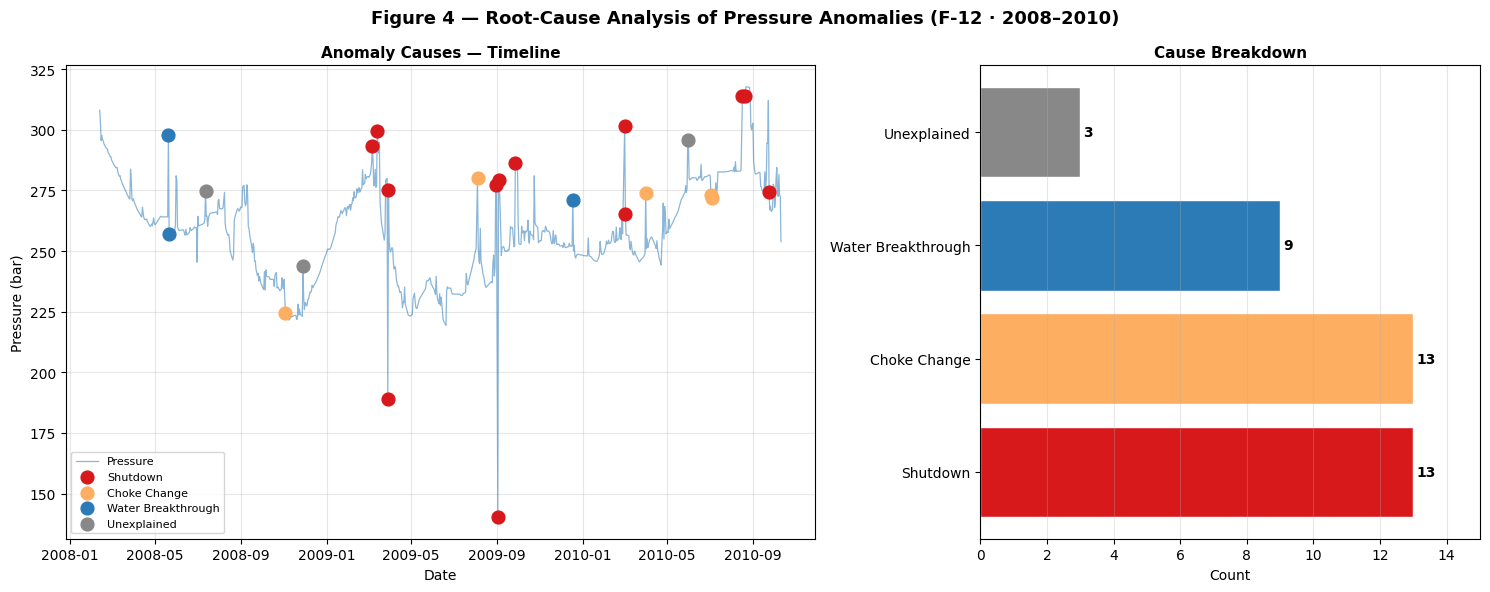

✅ Figure 4 saved


In [17]:
# ══════════════════════════════════════════════════════════════
# FIGURE 4 — Root-Cause Analysis
# ══════════════════════════════════════════════════════════════

# Expand multi-cause rows
primary_causes = master['Cause'].apply(lambda x: x.split(', ')[0])
all_cause_rows = [c.strip() for row in master['Cause'] for c in row.split(', ')]
cause_series   = pd.Series(all_cause_rows)

fig4 = plt.figure(figsize=(15, 6))
gs   = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1], figure=fig4)

# Left: timeline coloured by primary cause
ax4a = fig4.add_subplot(gs[0])
ax4a.plot(p.index, p, color=C['pressure'], linewidth=0.9, alpha=0.55, label='Pressure')
for cause, colour in cause_palette.items():
    sub = master[primary_causes == cause]
    if not sub.empty:
        ax4a.scatter(sub.index, sub['Pressure'], color=colour, s=85,
                     zorder=5, label=cause)
ax4a.set_title('Anomaly Causes — Timeline', fontsize=11, fontweight='bold')
ax4a.set_xlabel('Date'); ax4a.set_ylabel('Pressure (bar)')
ax4a.legend(fontsize=8); ax4a.grid(True, alpha=0.3)

# Right: horizontal bar chart
ax4b = fig4.add_subplot(gs[1])
cause_counts = cause_series.value_counts()
bar_colors   = [cause_palette.get(c, '#999') for c in cause_counts.index]
bars = ax4b.barh(cause_counts.index, cause_counts.values, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, cause_counts.values):
    ax4b.text(bar.get_width() + 0.08, bar.get_y() + bar.get_height()/2,
              str(val), va='center', fontsize=10, fontweight='bold')
ax4b.set_xlabel('Count'); ax4b.set_xlim(0, cause_counts.max() + 2)
ax4b.set_title('Cause Breakdown', fontsize=11, fontweight='bold')
ax4b.grid(True, alpha=0.3, axis='x')

fig4.suptitle('Figure 4 — Root-Cause Analysis of Pressure Anomalies (F-12 · 2008–2010)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('F12_Fig4_Causes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 4 saved')

---
## STEP 12 — Final Summary Report

In [18]:
def count_cause(keyword):
    return int(primary_causes.str.contains(keyword, case=False, na=False).sum())

total_readings = len(df_press)
total_anom = len(master)

shutdown_n = count_cause('Shutdown')
choke_n = count_cause('Choke')
water_n = count_cause('Water')
gas_n = count_cause('Gas')
unexplained_n = count_cause('Unexplained')

high_n = int((master['Confidence'] == 'High').sum())
med_n = int((master['Confidence'] == 'Medium').sum())
low_n = int((master['Confidence'] == 'Low').sum())

report = f"""
F-12 PRESSURE ANOMALY DETECTION – FINAL RESULTS


Well                     : NO 15/9-F-12 H
Period                   : 2008 – 2010

Total valid pressure readings : {total_readings}
Total anomalies detected      : {total_anom}

CONFIDENCE LEVELS
-----------------
High Confidence   : {high_n}
Medium Confidence : {med_n}
Low Confidence    : {low_n}

ROOT CAUSES
-----------
Shutdown-related   : {shutdown_n}
Choke Change       : {choke_n}
Water Breakthrough : {water_n}
Gas Coning         : {gas_n}
Unexplained        : {unexplained_n}
"""

print(report)

with open('F12_anomaly_report.txt', 'w') as f:
    f.write(report)

print("\n✅ Report saved: F12_anomaly_report.txt")


F-12 PRESSURE ANOMALY DETECTION – FINAL RESULTS


Well                     : NO 15/9-F-12 H
Period                   : 2008 – 2010

Total valid pressure readings : 955
Total anomalies detected      : 24

CONFIDENCE LEVELS
-----------------
High Confidence   : 1
Medium Confidence : 8
Low Confidence    : 15

ROOT CAUSES
-----------
Shutdown-related   : 13
Choke Change       : 5
Water Breakthrough : 3
Gas Coning         : 0
Unexplained        : 3


✅ Report saved: F12_anomaly_report.txt
